# Imports & Splitting the FF++ Dataset

In [1]:
import os
import random
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import kagglehub

from torchvision import datasets, models
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

from sklearn.metrics import classification_report, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device ", device)

Using device  cuda


In [3]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DATA_ROOT = "/kaggle/input/datasets/adham7elmy/faceforencispp-extracted-frames"

REAL_DIR = os.path.join(DATA_ROOT, "real")
FAKE_DIR = os.path.join(DATA_ROOT, "fake")

OUTPUT_DIR = "/kaggle/working/ffpp_split"

In [4]:
# look inside real_dir and return al the sub folders
def get_real_ids(real_dir):
    return sorted([d for d in os.listdir(real_dir) if os.path.isdir(os.path.join(real_dir, d))])

# build a dictionary where each key is fake generation method and each value is set of source IDs found for that method
def get_fake_source_ids(fake_dir):
    method_to_sources = defaultdict(set)
    
    for method in os.listdir(fake_dir):
        method_path = os.path.join(fake_dir, method)
        if not os.path.isdir(method_path):
            continue
        
        for video in os.listdir(method_path):
            source_id = video.split("_")[0]
            method_to_sources[method].add(source_id)
    
    return method_to_sources

In [5]:
def split_ids(ids, train_ratio=0.7, val_ratio=0.15):
    random.shuffle(ids)
    
    n = len(ids)
    train = ids[:int(n * train_ratio)]
    val = ids[int(n * train_ratio):int(n * (train_ratio + val_ratio))]
    test = ids[int(n * (train_ratio + val_ratio)):]
    
    return train, val, test

real_ids = get_real_ids(REAL_DIR)
train_ids, val_ids, test_ids = split_ids(real_ids)

In [6]:
def copy_images(src_dir, dst_dir, max_frames=10):
    os.makedirs(dst_dir, exist_ok=True)
    
    images = os.listdir(src_dir)

    # randomly sample frames
    if len(images) > max_frames:
        images = random.sample(images, max_frames)

    for img in images:
        src_path = os.path.join(src_dir, img)

        # prevent filename collision
        new_name = f"{os.path.basename(src_dir)}_{img}"
        dst_path = os.path.join(dst_dir, new_name)

        shutil.copy(src_path, dst_path)


def prepare_split():
    # remove old split 
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)

    # create folders
    for split in ["train", "val", "test"]:
        for cls in ["real", "fake"]:
            os.makedirs(os.path.join(OUTPUT_DIR, split, cls), exist_ok=True)

    # real
    for split, ids in zip(["train", "val", "test"], [train_ids, val_ids, test_ids]):
        for vid in ids:
            src = os.path.join(REAL_DIR, vid)
            dst = os.path.join(OUTPUT_DIR, split, "real")
            copy_images(src, dst)

    # fake
    for method in os.listdir(FAKE_DIR):
        method_path = os.path.join(FAKE_DIR, method)

        for video in os.listdir(method_path):
            source_id = video.split("_")[0]

            if source_id in train_ids:
                split = "train"
            elif source_id in val_ids:
                split = "val"
            else:
                split = "test"

            src = os.path.join(method_path, video)
            dst = os.path.join(OUTPUT_DIR, split, "fake")
            copy_images(src, dst)


prepare_split()

In [7]:
for dirname, _, filenames in os.walk('/kaggle/input/working'):
    print(dirname)

# Data Preprocessing

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1,0.1,0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
train_dataset = datasets.ImageFolder(os.path.join(OUTPUT_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(OUTPUT_DIR, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(OUTPUT_DIR, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [10]:
# train_dataset.classes
train_dataset[1]
print(train_dataset[0][0].shape)

torch.Size([3, 224, 224])


In [11]:
print(test_dataset.classes)
print(test_dataset.class_to_idx)

['fake', 'real']
{'fake': 0, 'real': 1}


# Load Pretrained Model

In [12]:
# load EfficientNet architecture with pretrained weights on imagenet
# model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
# model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# check how many features replace only the final layer
if isinstance(model, torchvision.models.ResNet):
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.BatchNorm1d(num_features),
        nn.Dropout(0.3),
        nn.Linear(num_features, 2)
    )

    for param in model.fc.parameters():
        param.requires_grad = True

else:
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(num_features),
        nn.Dropout(0.3),
        nn.Linear(num_features, 2)
    )

    for param in model.classifier.parameters():
        param.requires_grad = True


# move the model to correct hardware
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


In [13]:
train_targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(train_targets)

class_weights = torch.tensor(
    [len(train_targets) / c for c in class_counts],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

# Model Training Function

In [14]:
def train(model, loader, optimizer, criterion):

    model.train()
    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # forward pass, feed images through nn
        outputs = model(images)

        loss = criterion(outputs, labels)

        # reset gradient so they dont accumulate across batches
        optimizer.zero_grad()
        # gradient of the loss with respect to each weight
        loss.backward()
        # Adam optimizer updates the weight
        optimizer.step()

        # loss.item() converts the loss tensor into a Python number to calc avg loss later
        running_loss += loss.item()
    # return average loss per batch/epoch
    return running_loss / len(loader)

# Model Evaluation Function

In [15]:
def evaluate(model, loader):
    # switch the nn into evaluation mode i.e to disable dropout
    model.eval()

    # lists to store predicted labels and true labels
    all_preds = []
    all_labels = []

    # we are not training, so do not compute gradients
    with torch.no_grad():
        for images, labels in loader:

            # move images to the same hardware as model
            images = images.to(device)
            # forward pass, feed images through nn
            outputs = model(images)

            # find the highest value along a dimension
            _, preds = torch.max(outputs, 1)
            # move predictions back to CPU and save them in lists
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    # return true labels and predicted labels
    return all_labels, all_preds

# Training Loop

In [16]:
os.makedirs("/kaggle/working/models", exist_ok=True)

In [17]:
epochs = 30

train_losses = []

best_val_acc = 0
patience = 5
counter = 0

for epoch in range(epochs):

    if epoch == 3:
        print("Unfreezing last 5 blocks or 3 layers")
        
        if isinstance(model, torchvision.models.ResNet):
            for layer in [model.layer2, model.layer3, model.layer4]:
                for param in layer.parameters():
                    param.requires_grad = True
        else:
            for param in model.features[-5:].parameters():
                param.requires_grad = True

        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-5
        )

    loss = train(model, train_loader, optimizer, criterion)
    train_losses.append(loss)
    
    val_labels, val_preds = evaluate(model, val_loader)
    val_accuracy = np.mean(np.array(val_labels) == np.array(val_preds))

    print(f"Epoch {epoch+1}/{epochs}")
    print("Train loss:", loss)
    print("Val accuracy:", val_accuracy)
    print()

    # Early stopping 
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        counter = 0
        torch.save(model.state_dict(), "/kaggle/working/models/best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1/30
Train loss: 0.7272054671645164
Val accuracy: 0.52596167909902

Epoch 2/30
Train loss: 0.6754100771546364
Val accuracy: 0.580517770952172

Epoch 3/30
Train loss: 0.6539442143440246
Val accuracy: 0.6099166301009215

Unfreezing last 5 blocks or 3 layers
Epoch 4/30
Train loss: 0.5952645371854305
Val accuracy: 0.6404855930963873

Epoch 5/30
Train loss: 0.4834783567339182
Val accuracy: 0.722392862366535

Epoch 6/30
Train loss: 0.3947348756790161
Val accuracy: 0.7662717566183999

Epoch 7/30
Train loss: 0.3331159124597907
Val accuracy: 0.7950855638437911

Epoch 8/30
Train loss: 0.2814132737442851
Val accuracy: 0.8313587830919994

Epoch 9/30
Train loss: 0.2465293029472232
Val accuracy: 0.8512505484861781

Epoch 10/30
Train loss: 0.21146087608486414
Val accuracy: 0.8651455316659353

Epoch 11/30
Train loss: 0.19017069754190744
Val accuracy: 0.8733362585929502

Epoch 12/30
Train loss: 0.16768347060307862
Val accuracy: 0.8800643557115694

Epoch 13/30
Train loss: 0.15548004087805747
Val a

# Model Metrics

In [18]:
labels, preds = evaluate(model, test_loader)
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      5398
           1       0.75      0.85      0.79      1500

    accuracy                           0.90      6898
   macro avg       0.85      0.88      0.87      6898
weighted avg       0.91      0.90      0.91      6898



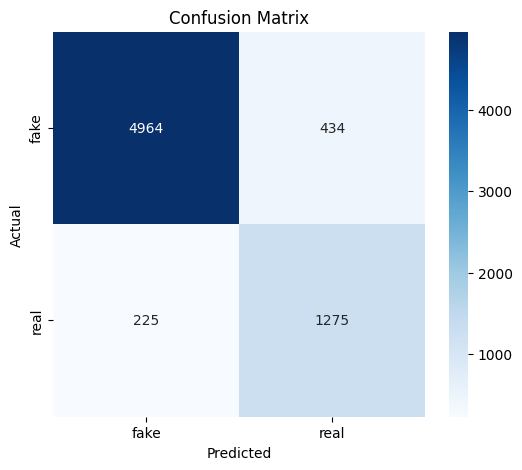

              precision    recall  f1-score   support

        fake       0.96      0.92      0.94      5398
        real       0.75      0.85      0.79      1500

    accuracy                           0.90      6898
   macro avg       0.85      0.88      0.87      6898
weighted avg       0.91      0.90      0.91      6898



In [19]:
all_labels, all_preds = evaluate(model, test_loader)

class_names = test_dataset.classes  # ['fake', 'real']

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

# Save Model

In [20]:
os.makedirs("/kaggle/working/models", exist_ok=True)
torch.save(model.state_dict(), "/kaggle/working/models/best_model_final.pth")